## Dataset

> The dataset for this homework is derived from the text8 collection, which comes from Wikipedia. Your method will use character-level tokenization and operate over text8 sequences that are each exactly 20 characters long. Only 27 character types are present (lowercase characters and spaces); special characters are replaced by a single space and numbers are spelled out as individual digits (50 becomes five zero). Part of examples are:
> 
> - heir average albedo
> - ed by rank and file
> - s can also extend in
> - erages between nine
> - that civilization n
> - on a t shaped islan
> 
> The dataset is in lettercounting-train.txt and lettercounting-dev.txt. Both two files contain character strings of length 20. You can assume that your model will always see 20 characters as input and make a prediction at each position in the sequence.

## Code

> The framework code you are given consists of several files.
> 1. *utils.py*: it implements an Indexer class, which can be used to maintain a bijective mapping between indices and features (strings).
> 2. *letter_counting.py*: contains the driver code, which imports transformer.py, the file you will be editing for this assignment.
> 3. *transformer.py*: **You need to fill out all missing parts. Note that your solutions should not use nn.TransformerEncoder, nn.TransformerDecoder, or any other off-the-shelf self-attention layers. You can use nn.Linear, nn.Embedding, and PyTorch’s provided nonlinearities / loss functions to implement Transformers from scratch.**


In [13]:
!python letter_counting.py --task BEFORE

Namespace(task='BEFORE', train='data/lettercounting-train.txt', dev='data/lettercounting-dev.txt', output_bundle_path='classifier-output.json')
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', ' ']
10000 lines read in
1000 lines read in
INPUT 0: heir average albedo 
GOLD 0: array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 2, 1, 2, 0, 0, 2, 0, 0, 2])
PRED 0: array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 2, 1, 2, 0, 0, 2, 0, 0, 2])
INPUT 1: ed by rank and file 
GOLD 1: array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 0, 0, 1, 2])
PRED 1: array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 0, 0, 1, 2])
INPUT 2: s can also extend in
GOLD 2: array([0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 2, 0, 0, 0, 1, 1, 0, 2, 0, 2])
PRED 2: array([0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 2, 0, 0, 0, 1, 1, 0, 2, 0, 2])
INPUT 3: erages between nine 
GOLD 3: array([0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 1, 0, 2, 2, 2])
PRED 3: array([0, 0, 0, 0, 1,

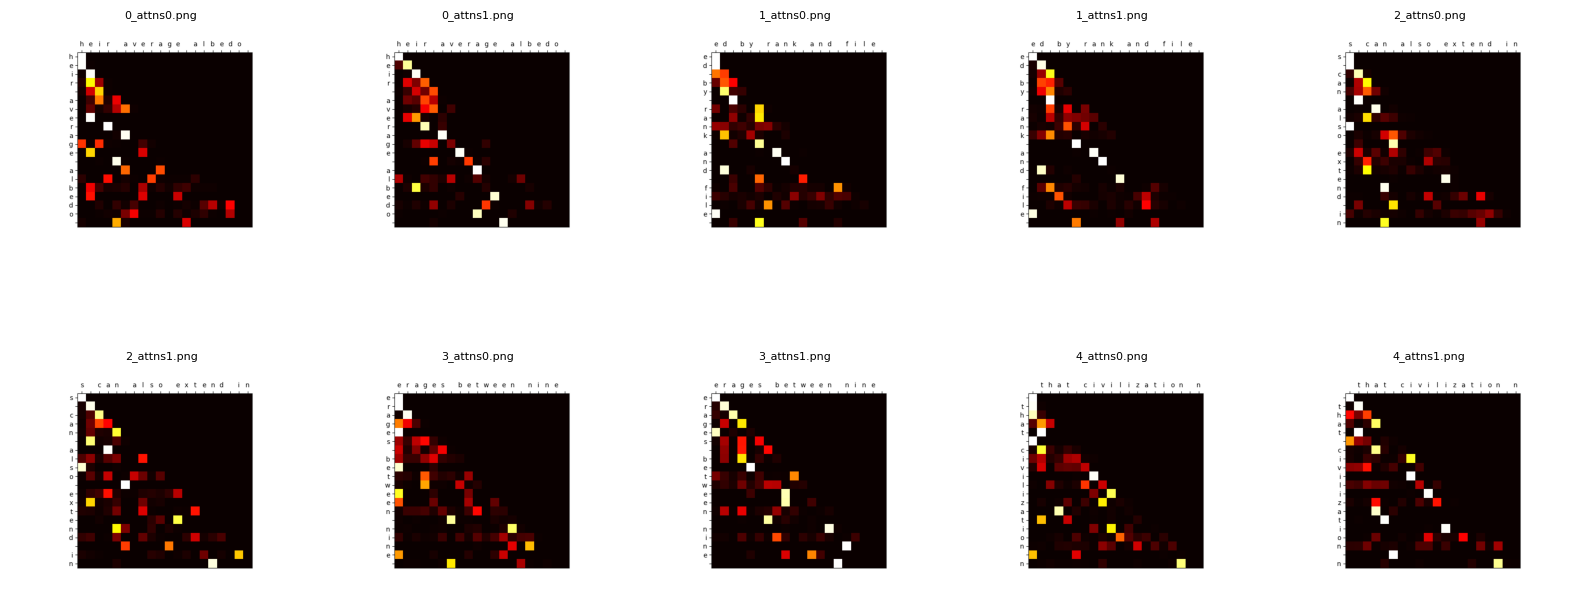

In [ ]:
# Your output
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

folder_path = 'plots_before'
image_files = [f for f in os.listdir(folder_path) ]
cols = 5
rows = (len(image_files) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i in range(len(image_files), len(axes)):
    axes[i].axis('off')

for ax, filename in zip(axes, image_files):
    file_path = os.path.join(folder_path, filename)
    img = mpimg.imread(file_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(filename), fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [1]:
!python letter_counting.py --task BEFOREAFTER 

Namespace(task='BEFOREAFTER', train='data/lettercounting-train.txt', dev='data/lettercounting-dev.txt', output_bundle_path='classifier-output.json')
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', ' ']
10000 lines read in
1000 lines read in
Epoch 0 loss: 3495.508222
Epoch 1 loss: 940.713553
Epoch 2 loss: 589.984107
Epoch 3 loss: 447.502270
Epoch 4 loss: 375.412930
Epoch 5 loss: 343.581351
Epoch 6 loss: 308.901160
Epoch 7 loss: 293.682319
Epoch 8 loss: 277.308157
Epoch 9 loss: 270.606194
INPUT 0: heir average albedo 
GOLD 0: array([0, 2, 0, 1, 2, 2, 0, 2, 1, 2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 2])
PRED 0: array([0, 2, 0, 1, 2, 2, 0, 2, 1, 2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 2])
INPUT 1: ed by rank and file 
GOLD 1: array([1, 1, 2, 0, 0, 2, 0, 1, 1, 0, 2, 1, 1, 1, 2, 0, 0, 0, 1, 2])
PRED 1: array([1, 1, 2, 0, 0, 2, 0, 1, 1, 0, 2, 1, 1, 1, 2, 0, 0, 0, 1, 2])
INPUT 2: s can also extend in
GOLD 2: array([1, 2, 0, 1, 2, 2

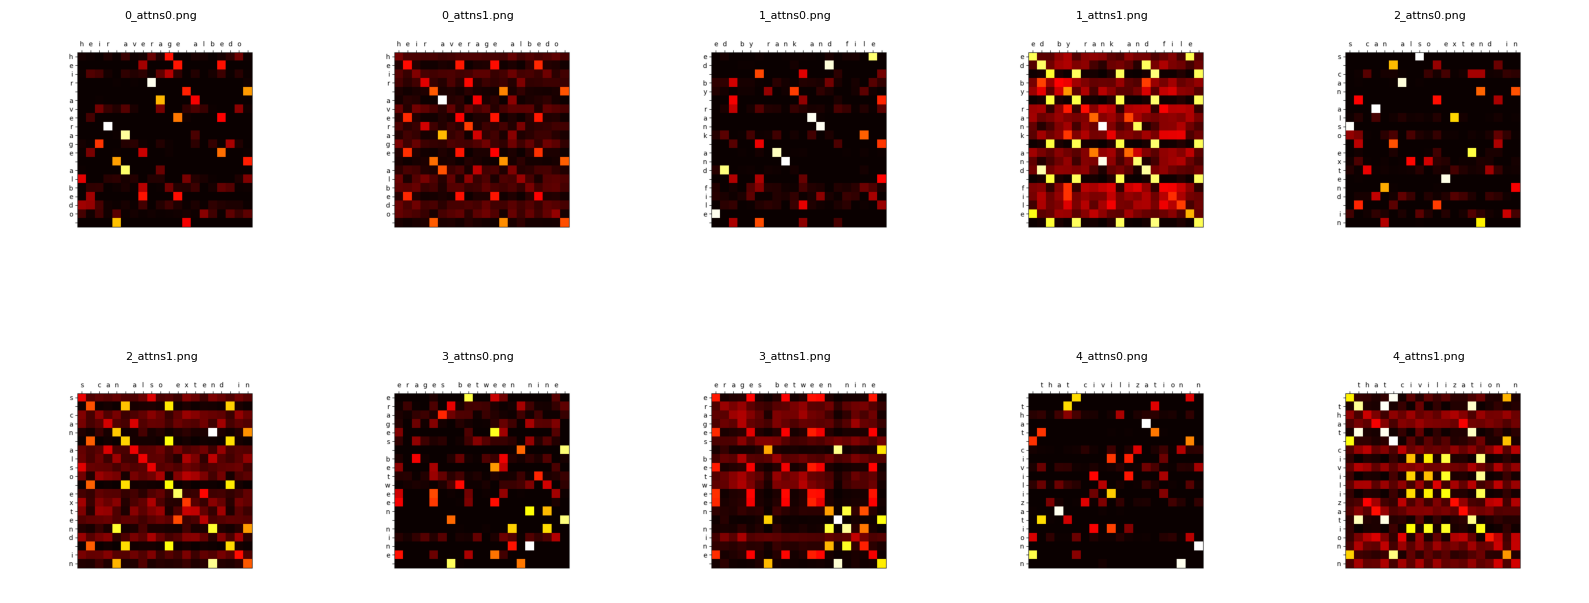

In [ ]:
# Your output
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

folder_path = 'plots_beforeafter'
image_files = [f for f in os.listdir(folder_path) ]
cols = 5
rows = (len(image_files) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i in range(len(image_files), len(axes)):
    axes[i].axis('off')

for ax, filename in zip(axes, image_files):
    file_path = os.path.join(folder_path, filename)
    img = mpimg.imread(file_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(filename), fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

- This assignment was mainly adopted from [link](https://www.cs.utexas.edu/~gdurrett/courses/online-course/a3.pdf).

**upload your homework: use html file format**

!jupyter nbconvert assignment-02-XXX-YYY.ipynb --to html --template classic --embed-images

In [3]:
!jupyter nbconvert assignment-02-YourStudentID-ChineseName.ipynb --to html --template classic --embed-images

[NbConvertApp] Converting notebook assignment-02-YourStudentID-ChineseName.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 473213 bytes to assignment-02-YourStudentID-ChineseName.html
